<a href="https://colab.research.google.com/github/SofiaDomeli/Neural_Network_HS/blob/titanic/RedesNeurais_Titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <center> 🧊 Rede Neural Titanic 🚢 </center>

por Heny Dorta e Sofia Domingues 😼

### 1. Bibliotecas

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential # type: ignore
from tensorflow.keras.layers import Dense # type: ignore
from tensorflow.keras.initializers import GlorotUniform # type: ignore

from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

### 2. Variáveis e Ambiente

In [2]:
df = pd.DataFrame(sns.load_dataset('titanic')).drop(columns=['alive'])

df = df.astype({
    "survived": "int8",
    "pclass": "int8",
    "sibsp": "int8",
    "parch": "int8",
    "age": "float32",
    "fare": "float32"
})

atributos = df.drop(columns=['survived'], axis=1)
resposta = np.array(df['survived'])

df.dtypes

,0
survived,int8
pclass,int8
sex,object
age,float32
sibsp,int8
parch,int8
fare,float32
embarked,object
class,category
who,object


### Pré-processamento

In [3]:
# Resposta
label_encoder = LabelEncoder()

# Atributos
preprocessador = ColumnTransformer(
    transformers=[
        ('categoricas', OrdinalEncoder(), make_column_selector(dtype_include=['object', 'bool', 'category'])),
    ],
    remainder='passthrough', # Preserva as colunas que não foram transformadas
    verbose_feature_names_out = False
)

In [4]:
atributos = pd.DataFrame(data=preprocessador.fit_transform(atributos), columns=preprocessador.get_feature_names_out())
resposta = label_encoder.fit_transform(resposta)

#### 3.1 Divisão treino e teste

In [5]:
atributos_treino, atributos_teste, resposta_treino, resposta_teste = train_test_split(atributos, resposta, test_size=0.2, random_state=42)

### 4. Implementação - Hidden Layers

In [6]:
# modelo sequencial: 2 neurônios na oculta, 1 na saída
model = Sequential()
model.add(Dense(6, input_dim=atributos.shape[1], activation='sigmoid',
                kernel_initializer=GlorotUniform(seed=42)))
model.add(Dense(1, activation='sigmoid',
                kernel_initializer=GlorotUniform(seed=42)))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
# compile - 'contrato de treino'
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

### 5. Treino do modelo

In [8]:
print(type(atributos_treino))

<class 'pandas.core.frame.DataFrame'>


In [9]:
# treinamento com armazenamneto do historico
history = model.fit(atributos_treino, resposta_treino, epochs=100, verbose=0)

### 6. Avaliação do modelo

In [10]:
# avaliacao final
loss, accuracy = model.evaluate(atributos_teste, resposta_teste, verbose=0)
print(f'\n--> Avaliação final no conjunto de treino')
print(f'Loss final: {loss:.2f}')
print(f'Acúracia final: {accuracy:.2f}')

# historico
print(f'\nNúmero de épocas treinadas: {len(history.history['loss'])}')
print(f'Último loss registrado: {history.history['loss'][-1]:.4f}')
print(f'Últimaa acurácia registrada: {history.history['accuracy'][-1]:.4f}')


--> Avaliação final no conjunto de treino
Loss final: nan
Acúracia final: 0.59

Número de épocas treinadas: 100
Último loss registrado: nan
Últimaa acurácia registrada: 0.6236


#### 6.1 Gráfico de Avalição [ Em Desenvolvimento ]

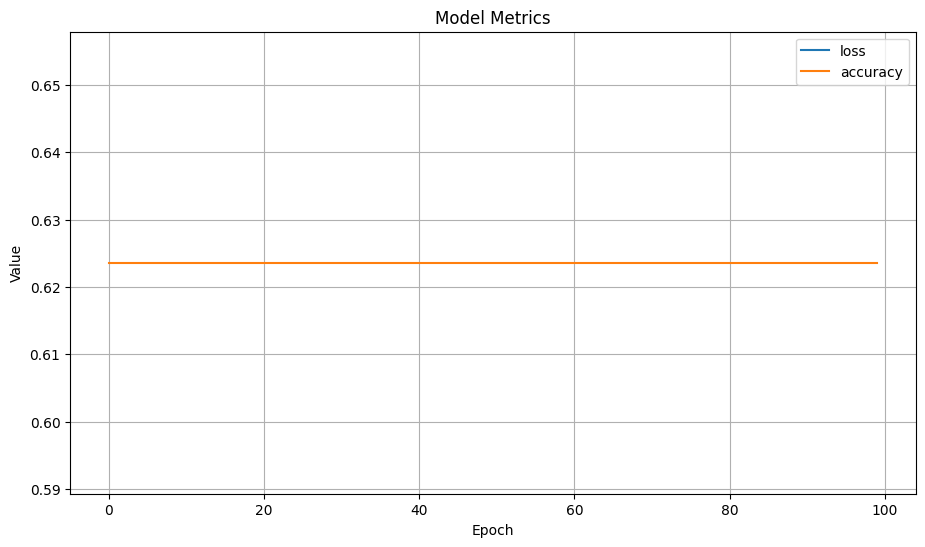

In [11]:
plt.figure(figsize=(24, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['accuracy'], label='accuracy')
plt.title('Model Metrics')
plt.ylabel('Value')
plt.xlabel('Epoch')
plt.legend()
plt.grid()
plt.show()

In [ ]:
from itertools import product

def criar_modelo(neuronios=2, camadas=1, ativacao='sigmoid', otimizador='adam'):
    model = Sequential()
    # primeira camada oculta
    model.add(Dense(neuronios, input_dim=atributos_treino.shape[1],
                    activation=ativacao, kernel_initializer=GlorotUniform(seed=42)))
    # camadas adicionais
    for _ in range(camadas - 1):
        model.add(Dense(neuronios, activation=ativacao,
                        kernel_initializer=GlorotUniform(seed=42)))
    # saída
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer=otimizador, loss='binary_crossentropy', metrics=['accuracy'])
    return model


param_grid = {
    'neuronios': [2, 4, 8, 16, 32],
    'camadas': [1, 2, 3],
    'ativacao': ['sigmoid', 'relu', 'tanh'],
    'otimizador': ['adam', 'sgd'],
    'epochs': [100]
}

melhor_acc = 0
melhores_params = None
historico_resultados = []

for valores in product(*param_grid.values()):
    params = dict(zip(param_grid.keys(), valores))

    model = criar_modelo(
        neuronios=params['neuronios'],
        camadas=params['camadas'],
        ativacao=params['ativacao'],
        otimizador=params['otimizador']
    )

    history = model.fit(
        atributos_treino, resposta_treino,
        epochs=100,
        verbose=0
    )

    loss, acc = model.evaluate(atributos_teste, resposta_teste, verbose=0)

    historico_resultados.append((params, acc))

    if acc > melhor_acc:
        melhor_acc = acc
        melhores_params = params

    print(f'Testado: {params} -> Acurácia teste: {acc:.4f}')

print('\nMelhores parâmetros encontrados:')
print(melhores_params)
print(f'Acurácia no teste: {melhor_acc:.4f}')


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Testado: {'neuronios': 2, 'camadas': 1, 'ativacao': 'sigmoid', 'otimizador': 'adam', 'epochs': 100} -> Acurácia teste: 0.5866


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Testado: {'neuronios': 2, 'camadas': 1, 'ativacao': 'sigmoid', 'otimizador': 'sgd', 'epochs': 100} -> Acurácia teste: 0.5866


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Testado: {'neuronios': 2, 'camadas': 3, 'ativacao': 'relu', 'otimizador': 'adam', 'epochs': 100} -> Acurácia teste: 0.5866


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Testado: {'neuronios': 2, 'camadas': 3, 'ativacao': 'relu', 'otimizador': 'sgd', 'epochs': 100} -> Acurácia teste: 0.5866


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
